In [ ]:
"""“Analyzed a synthetic e-commerce dataset to study customer behavior, product performance, 
and marketing effectiveness, and applied K-Means clustering to segment products 
and customers for data-driven business insights.”"""

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle 

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('synthetic_ecommerce_data.csv')
df.head()

,Transaction_ID,Customer_ID,Product_ID,Transaction_Date,Units_Sold,Discount_Applied,Revenue,Clicks,Impressions,Conversion_Rate,Category,Region,Ad_CTR,Ad_CPC,Ad_Spend
0,8b460852-7c64-46fa-998b-b0976879d082,Customer_65,Product_224,2024-10-06,134,0.14,305.54,11,65,0.17,Electronics,Europe,0.0180,0.55,9.90
1,418612e7-8744-4ba3-bb0c-105b47e2a968,Customer_1910,Product_584,2024-10-29,109,0.30,1102.19,15,201,0.07,Home Appliances,Asia,0.1589,0.40,63.56
2,5bc3b98f-cb0c-4b12-947c-df8bbb35a73e,Customer_2306,Product_374,2024-04-04,116,0.04,471.29,16,199,0.08,Toys,Asia,0.0596,1.50,89.40
3,28fb67c8-e8c0-447a-841c-f760730de0eb,Customer_17206,Product_220,2024-08-25,125,0.20,980.26,12,355,0.03,Clothing,Europe,0.0444,0.44,19.54
4,8bee087a-a8a9-45bb-89d7-04d1710f1b00,Customer_16033,Product_358,2024-05-05,132,0.07,803.76,44,355,0.12,Books,North America,0.1270,0.53,67.31


In [9]:
df =  df.drop(columns=[
    "Transaction_Date",   
    "Category",           
    "Region",             
    "Clicks",             
    "Impressions",       
    "Ad_CTR",             
    "Ad_CPC" ])

In [10]:
df.head()

,Transaction_ID,Customer_ID,Product_ID,Units_Sold,Discount_Applied,Revenue,Conversion_Rate,Ad_Spend
0,8b460852-7c64-46fa-998b-b0976879d082,Customer_65,Product_224,134,0.14,305.54,0.17,9.90
1,418612e7-8744-4ba3-bb0c-105b47e2a968,Customer_1910,Product_584,109,0.30,1102.19,0.07,63.56
2,5bc3b98f-cb0c-4b12-947c-df8bbb35a73e,Customer_2306,Product_374,116,0.04,471.29,0.08,89.40
3,28fb67c8-e8c0-447a-841c-f760730de0eb,Customer_17206,Product_220,125,0.20,980.26,0.03,19.54
4,8bee087a-a8a9-45bb-89d7-04d1710f1b00,Customer_16033,Product_358,132,0.07,803.76,0.12,67.31


In [12]:
df = df.drop(columns=['Transaction_ID','Customer_ID'])

In [13]:
df.head()

,Product_ID,Units_Sold,Discount_Applied,Revenue,Conversion_Rate,Ad_Spend
0,Product_224,134,0.14,305.54,0.17,9.90
1,Product_584,109,0.30,1102.19,0.07,63.56
2,Product_374,116,0.04,471.29,0.08,89.40
3,Product_220,125,0.20,980.26,0.03,19.54
4,Product_358,132,0.07,803.76,0.12,67.31


In [14]:
product_df = df.groupby('Product_ID').agg({
    'Units_Sold':'sum',
    'Discount_Applied':'mean',
    'Revenue':'sum',
    'Conversion_Rate':'mean',
    'Ad_Spend':'sum'
}).reset_index()

In [16]:
product_df.head()

,Product_ID,Units_Sold,Discount_Applied,Revenue,Conversion_Rate,Ad_Spend
0,Product_1,15323,0.160091,7923.76,0.183909,12223.70
1,Product_10,15951,0.156508,57270.66,0.202698,12765.14
2,Product_100,13484,0.142453,89691.68,0.206226,11658.75
3,Product_1000,12094,0.139888,81266.38,0.231685,11380.91
4,Product_101,13366,0.152549,17539.97,0.145490,12546.62


In [18]:
X = product_df[['Units_Sold','Discount_Applied','Revenue','Conversion_Rate','Ad_Spend']]

In [19]:
X.head()

,Units_Sold,Discount_Applied,Revenue,Conversion_Rate,Ad_Spend
0,15323,0.160091,7923.76,0.183909,12223.70
1,15951,0.156508,57270.66,0.202698,12765.14
2,13484,0.142453,89691.68,0.206226,11658.75
3,12094,0.139888,81266.38,0.231685,11380.91
4,13366,0.152549,17539.97,0.145490,12546.62


In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [26]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

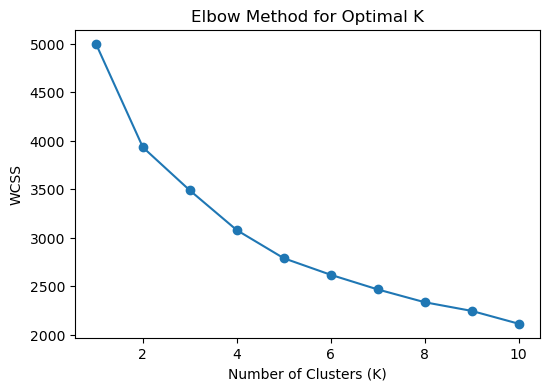

In [28]:
plt.figure(figsize=(6,4)),
plt.plot(range(1, 11),wcss,marker = 'o'),
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()

In [32]:
kmeans = KMeans(n_clusters=3, random_state=42)
product_df['Cluster'] = kmeans.fit_predict(X_scaled)

In [33]:
pickle.dump(scaler,open('scaler.pkl','wb'))
pickle.dump(kmeans,open('kmeans_model.pkl','wb'))

print("✅ K-Means product clustering model trained and saved successfully")

✅ K-Means product clustering model trained and saved successfully
